In [10]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score 

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [4]:
crop = pd.read_csv("data/Crop_recommendation.csv")

crop_dict = {
    'rice': 1, 'maize': 2, 'jute': 3, 'cotton': 4, 'coconut': 5,
    'papaya': 6, 'orange': 7, 'apple': 8, 'muskmelon': 9, 'watermelon': 10,
    'grapes': 11, 'mango': 12, 'banana': 13, 'pomegranate': 14,
    'lentil': 15, 'blackgram': 16, 'mungbean': 17, 'mothbeans': 18,
    'pigeonpeas': 19, 'kidneybeans': 20, 'chickpea': 21, 'coffee': 22
}
reverse_crop_dict = {v: k for k, v in crop_dict.items()}
crop['soil_type'] = crop['soil_type'].map(crop_dict)

# Features & soil_types
X = crop.drop('soil_type', axis=1)
y = crop['soil_type']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
mx = MinMaxScaler()
X_train = mx.fit_transform(X_train)
X_test = mx.transform(X_test)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [11]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)

ensemble = VotingClassifier(estimators=[('rf', rf), ('gb', gb)], voting='soft')
ensemble.fit(X_train, y_train)

# Ensemble accuracy
y_pred = ensemble.predict(X_test)
print("Ensemble model accuracy:", accuracy_score(y_test, y_pred))

Ensemble model accuracy: 0.9840909090909091


In [6]:
crop_profit = {
    'rice': 24000, 'maize': 20000, 'banana': 45000, 'mango': 50000, 'grapes': 52000,
    'wheat': 23000, 'coffee': 60000, 'cotton': 28000, 'orange': 35000, 'apple': 48000,
    'papaya': 40000, 'jute': 30000, 'coconut': 55000, 'muskmelon': 48000, 'watermelon': 52000,
    'pomegranate': 64000, 'lentil': 27000, 'blackgram': 25000, 'mungbean': 26000,
    'mothbeans': 24000, 'pigeonpeas': 28000, 'kidneybeans': 29000, 'chickpea': 30000
}

In [ ]:
# Set up data generator with augmentation + validation split
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Training data generator
train_gen = datagen.flow_from_directory(
    r"C:\Users\191210v\OneDrive\Apps\MLProjects\data\Training set",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Validation data generator
val_gen = datagen.flow_from_directory(
    r"C:\Users\191210v\OneDrive\Apps\MLProjects\data\Training set",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)



Found 2459 images belonging to 5 classes.
Found 613 images belonging to 5 classes.


In [15]:
# ------------------------------------------
# CNN Model Definition
# ------------------------------------------

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# ------------------------------------------
# Callbacks: EarlyStopping + LR Scheduler + ModelCheckpoint
# ------------------------------------------

early_stop = EarlyStopping(
    monitor='val_accuracy',   # stop when val accuracy stops improving
    patience=5,
    restore_best_weights=True,
    mode='max'               
)

lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',        # reduce LR when loss plateaus
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_soil_cnn_model.h5',
    monitor='val_accuracy',   # save model with best accuracy
    save_best_only=True,
    mode='max',
    verbose=1
)

In [ ]:
# ------------------------------------------
# Train the Model
# ------------------------------------------

callbacks = [early_stop, lr_schedule, checkpoint]

history = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs = 50,
    callbacks = callbacks,
    verbose = 1
)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.9492 - loss: 0.1571
Epoch 1: val_loss improved from 0.25916 to 0.20004, saving model to best_soil_cnn_model.h5


77/77 ━━━━━━━━━━━━━━━━━━━━ 24s 307ms/step - accuracy: 0.9475 - loss: 0.1586 - val_accuracy: 0.9299 - val_loss: 0.2000 - learning_rate: 5.0000e-04
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.9564 - loss: 0.1321
Epoch 2: val_loss did not improve from 0.20004
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 277ms/step - accuracy: 0.9471 - loss: 0.1573 - val_accuracy: 0.9054 - val_loss: 0.2788 - learning_rate: 5.0000e-04
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9464 - loss: 0.1611
Epoch 3: val_loss did not improve from 0.20004
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 260ms/step - accuracy: 0.9504 - loss: 0.1505 - val_accuracy: 0.8744 - val_loss: 0.4367 - learning_rate: 5.0000e-04
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9477 - loss: 0.1585
Epoch 4: val_loss improved from 0.20004 to 0.17384, saving model to best_soil_cnn_model.h5


77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 265ms/step - accuracy: 0.9512 - loss: 0.1436 - val_accuracy: 0.9364 - val_loss: 0.1738 - learning_rate: 2.5000e-04
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9652 - loss: 0.1123
Epoch 5: val_loss did not improve from 0.17384
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 276ms/step - accuracy: 0.9634 - loss: 0.1149 - val_accuracy: 0.9413 - val_loss: 0.1934 - learning_rate: 2.5000e-04
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9651 - loss: 0.1120
Epoch 6: val_loss improved from 0.17384 to 0.16546, saving model to best_soil_cnn_model.h5


77/77 ━━━━━━━━━━━━━━━━━━━━ 24s 315ms/step - accuracy: 0.9585 - loss: 0.1258 - val_accuracy: 0.9445 - val_loss: 0.1655 - learning_rate: 2.5000e-04
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.9637 - loss: 0.1069
Epoch 7: val_loss did not improve from 0.16546
77/77 ━━━━━━━━━━━━━━━━━━━━ 23s 298ms/step - accuracy: 0.9626 - loss: 0.1078 - val_accuracy: 0.9347 - val_loss: 0.1981 - learning_rate: 2.5000e-04
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9618 - loss: 0.1042
Epoch 8: val_loss did not improve from 0.16546
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 280ms/step - accuracy: 0.9634 - loss: 0.1046 - val_accuracy: 0.9070 - val_loss: 0.3384 - learning_rate: 2.5000e-04
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.9634 - loss: 0.1113
Epoch 9: val_loss did not improve from 0.16546
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 279ms/step - accuracy: 0.9638 - loss: 0.1063 - val_accuracy: 0.9396 - val_loss: 0.1671 - learning_rate: 1.2500e-04


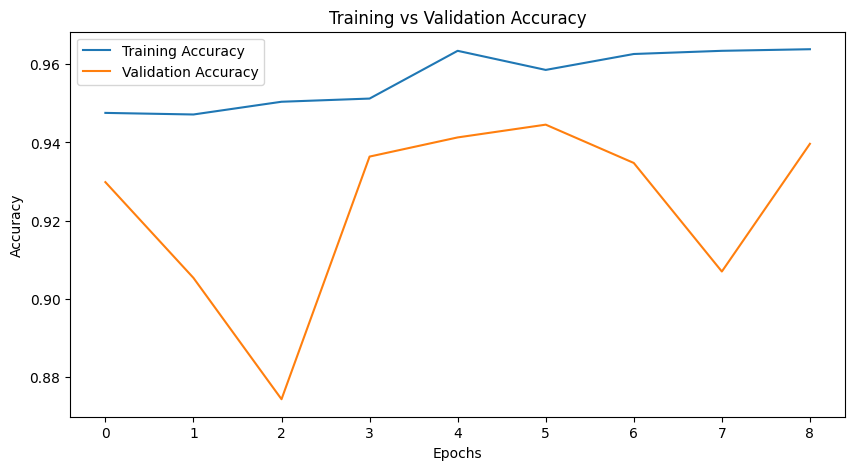

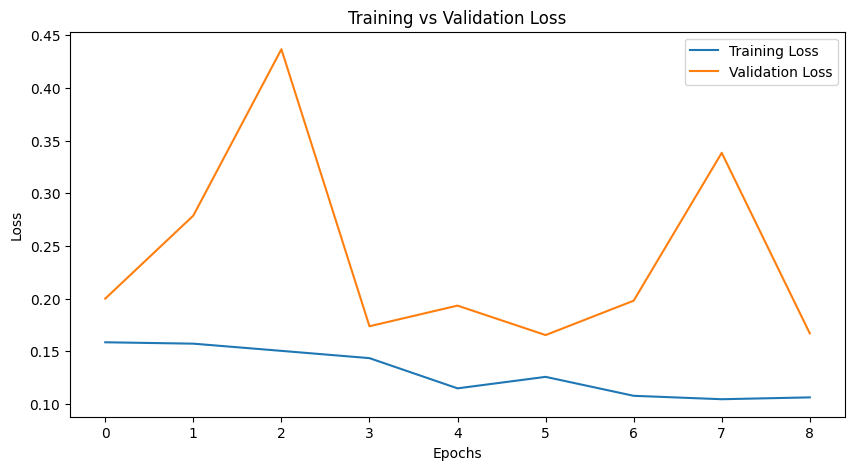

In [20]:

# ------------------------------------------
# Plot Training vs Validation Accuracy
# ------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ------------------------------------------
# Plot Training vs Validation Loss
# ------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ------------------------------------------
# Saving Final Model (Best weights already restored)
# ------------------------------------------

model.save("final_soil_cnn_model.h5")

In [21]:
soil_model = load_model('soil_cnn_model.h5')

improved mapping of Indian soil types and their estimated average nutrient values (N, P, K, pH) based on authoritative datasets and soil science references, including HWSD v2.0, SoilGrids, MoSPI, and agricultural research publications

In [22]:
soil_nutrients_set = {
    'alluvial soil': {
        'N': 40,    # kg/ha (SoilGrids/HWSD: moderate; MoSPI: often low-medium)
        'P': 11,    # kg/ha (MoSPI: usually low; HWSD: 10-15 typical)
        'K': 110,   # kg/ha (Alluvial: high K, per HWSD/FOSSEE)
        'pH': 7.2   # Neutral to slightly alkaline (HWSD/ICAR/FOSSEE)
    },
    'black soil': {
        'N': 32,    # kg/ha (MoSPI: low-medium; HWSD: 30-35 typical)
        'P': 10,    # kg/ha (HWSD: 10 medium; MoSPI: low)
        'K': 150,   # kg/ha (Black soil: excellent K, HWSD)
        'pH': 7.8   # Slightly alkaline (7.5-8.5, HWSD/FOSSEE)
    },
    'laterite soil': {
        'N': 15,    # kg/ha (MoSPI: low; HWSD: 10-20 typical)
        'P': 7,     # kg/ha (MoSPI: low; HWSD: <10 typical)
        'K': 18,    # kg/ha (Laterite: poor K, HWSD; MoSPI)
        'pH': 5.0   # Acidic (4.5-5.5, HWSD/MoSPI)
    },
    'red soil': {
        'N': 18,    # kg/ha (MoSPI: low; HWSD: 15-20 typical)
        'P': 9,     # kg/ha (HWSD/MoSPI: low)
        'K': 50,    # kg/ha (Red soil: fair K; HWSD)
        'pH': 6.2   # Slightly acidic/neutral (6-6.5, HWSD)
    },
    'yellow soil': {
        'N': 20,    # kg/ha (MoSPI: low-medium; HWSD: 18-22 typical)
        'P': 10,    # kg/ha (MoSPI/HWSD: low-medium)
        'K': 32,    # kg/ha (Yellow soil: medium K; HWSD)
        'pH': 6.0   # Slightly acidic (MoSPI/HWSD/FOSSEE)
    }
}

soil_classes = list(soil_nutrients_set.keys())  


In [23]:

def predict_soil_nutrients(img_path):
    img = load_img(img_path, target_size=(128,128))
    img_array = img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    pred = soil_model.predict(img_array)
    soil_class_index = np.argmax(pred)
    soil_type = soil_classes[soil_class_index]
    
    return soil_nutrients_set[soil_type], soil_type

In [24]:
API_KEY = "9145512fae70dc833bca6906ff40a492"

def fetch_live_weather(city_name, country_code='IN'):
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city_name},{country_code}&appid={API_KEY}&units=metric"
    data = requests.get(url).json()
    if data.get('cod') != 200:
        print("Weather API error:", data.get('message'))
        return None
    temp = data['main']['temp']
    humidity = data['main']['humidity']
    rain = data.get('rain', {}).get('1h', 0)
    return temp, humidity, rain


In [26]:
def recommend_top3(soil_img_path, city_name):
    nutrients, soil_type = predict_soil_nutrients(soil_img_path)
    weather = fetch_live_weather(city_name)
    
    if weather is None:
        temperature, humidity, rainfall = 25, 70, 100
    else:
        temperature, humidity, rainfall = weather
    
    features = np.array([[nutrients['N'], nutrients['P'], nutrients['K'],
                          temperature, humidity, nutrients['pH'], rainfall]])
    
    mx_features = mx.transform(features)
    sc_features = sc.transform(mx_features)
    
    probs = ensemble.predict_proba(sc_features)[0]
    labels = ensemble.classes_
    
    top3_idx = np.argsort(probs)[-3:][::-1]
    recommendations = []
    for idx in top3_idx:
        label = labels[idx]
        crop_name = reverse_crop_dict[label]
        confidence = round(probs[idx]*100, 2)
        profit = crop_profit.get(crop_name, 0)
        recommendations.append({
            "Crop": crop_name,
            "Confidence (%)": confidence,
            "Expected Profit (₹/acre)": profit
        })
    
    return pd.DataFrame(recommendations), soil_type

In [60]:
# List of soil image paths
soil_image_paths = [
    r"C:\Users\191210v\OneDrive\Apps\MLProjects\data\New soil images\Alluvial soil\alluvial soil img1.jpg",
    r"C:\Users\191210v\OneDrive\Apps\MLProjects\data\New soil images\Black soil\Black soil img2.jpg",
    r"C:\Users\191210v\OneDrive\Apps\MLProjects\data\New soil images\Laterite soil\laterite img1.jpg",
    r"C:\Users\191210v\OneDrive\Apps\MLProjects\data\New soil images\Red soil\Red soil img1.jpg",
    r"C:\Users\191210v\OneDrive\Apps\MLProjects\data\New soil images\Yellow soil\yellow soil img1.jpg"
]

city_name = "Tadepallegudem"

results = [] 

print("\n==== Batch Soil Testing Results ====\n")

for idx, soil_image_path in enumerate(soil_image_paths, start=1):
    print(f"--- Image {idx}: {soil_image_path} ---")

    try:
        top3_crops, soil_type = recommend_top3(soil_image_path, city_name)

        results.append({
            "image": soil_image_path,
            "soil_type": soil_type,
            "top3": top3_crops
        })

        print("Predicted Soil Type:", soil_type)
        print("Top 3 Recommended Crops:", top3_crops)

    except Exception as e:
        print("Error processing image:", e)
    
    print("----------------------------------------\n")




==== Batch Soil Testing Results ====

--- Image 1: C:\Users\191210v\OneDrive\Apps\MLProjects\data\New soil images\Alluvial soil\alluvial soil img1.jpg ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted Soil Type: alluvial soil
Top 3 Recommended Crops:           Crop  Confidence (%)  Expected Profit (₹/acre)
0    muskmelon           72.00                     48000
1  pomegranate            8.50                     64000
2       papaya            6.25                     40000
----------------------------------------

--- Image 2: C:\Users\191210v\OneDrive\Apps\MLProjects\data\New soil images\Black soil\Black soil img2.jpg ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


c:\Users\191210v\OneDrive\Apps\MLProjects\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Soil Type: black soil
Top 3 Recommended Crops:         Crop  Confidence (%)  Expected Profit (₹/acre)
0  muskmelon            69.5                     48000
1     grapes             7.5                     52000
2      apple             6.0                     48000
----------------------------------------

--- Image 3: C:\Users\191210v\OneDrive\Apps\MLProjects\data\New soil images\Laterite soil\laterite img1.jpg ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


c:\Users\191210v\OneDrive\Apps\MLProjects\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Soil Type: laterite soil
Top 3 Recommended Crops:         Crop  Confidence (%)  Expected Profit (₹/acre)
0  muskmelon           56.14                     48000
1   mungbean           18.86                     26000
2     orange           13.25                     35000
----------------------------------------

--- Image 4: C:\Users\191210v\OneDrive\Apps\MLProjects\data\New soil images\Red soil\Red soil img1.jpg ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


c:\Users\191210v\OneDrive\Apps\MLProjects\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Soil Type: red soil
Top 3 Recommended Crops:           Crop  Confidence (%)  Expected Profit (₹/acre)
0    muskmelon           74.25                     48000
1  pomegranate           11.75                     64000
2       papaya            5.50                     40000
----------------------------------------

--- Image 5: C:\Users\191210v\OneDrive\Apps\MLProjects\data\New soil images\Yellow soil\yellow soil img1.jpg ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


c:\Users\191210v\OneDrive\Apps\MLProjects\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Predicted Soil Type: yellow soil
Top 3 Recommended Crops:           Crop  Confidence (%)  Expected Profit (₹/acre)
0    muskmelon           59.93                     48000
1     mungbean           15.82                     26000
2  pomegranate           13.00                     64000
----------------------------------------



c:\Users\191210v\OneDrive\Apps\MLProjects\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


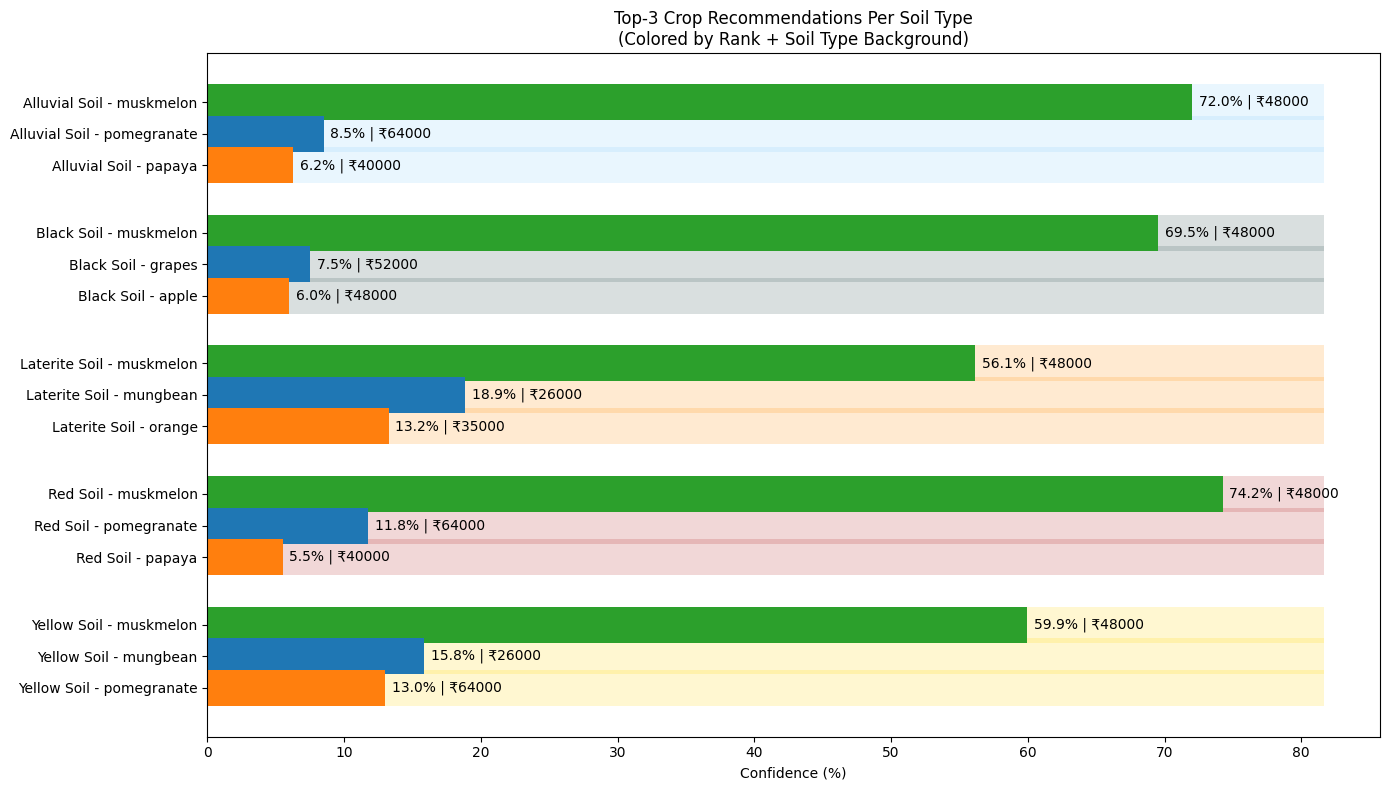

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Soil type → color mapping
soil_color_map = {
    "alluvial soil": "#87CEFA",  
    "black soil": "#2F4F4F",     
    "laterite soil": "#FF8C00",  
    "red soil": "#B22222",       
    "yellow soil": "#FFD700"     
}

# Prepare data
all_crops = []
all_conf = []
all_profit = []
soil_types = []

for item in results:
    df = item["top3"]
    crops = list(df["Crop"])
    conf = list(df["Confidence (%)"])
    profit = list(df["Expected Profit (₹/acre)"])
    
    all_crops.append(crops)
    all_conf.append(conf)
    all_profit.append(profit)
    soil_types.append(item["soil_type"].lower())  

# Crop rank colors
rank_colors = ["#2ca02c", "#1f77b4", "#ff7f0e"]

plt.figure(figsize=(14, 8))

y_positions = []
y_labels = []
bar_colors = []
conf_values = []
profit_values = []
soil_strip_colors = []

pos = 0

for img_idx, crops in enumerate(all_crops):

    soil_name = soil_types[img_idx].title()   # e.g., "Alluvial Soil"

    for i in range(3):  
        y_positions.append(pos)

        y_labels.append(f"{soil_name} - {crops[i]}")

        conf_values.append(all_conf[img_idx][i])
        profit_values.append(all_profit[img_idx][i])
        bar_colors.append(rank_colors[i])

        soil_strip_colors.append(
            soil_color_map.get(soil_types[img_idx], "gray")
        )

        pos -= 0.7

    pos -= 0.8  

# Background soil-type color strip
for y, strip_color in zip(y_positions, soil_strip_colors):
    plt.barh(y, max(conf_values) * 1.1, 
             color=strip_color, alpha=0.18)

# Main crop-confidence bars
plt.barh(y_positions, conf_values, color=bar_colors)

# Add confidence + expected profit text
for y, conf, profit in zip(y_positions, conf_values, profit_values):
    plt.text(conf + 0.5, y,
             f"{conf:.1f}% | ₹{profit}",
             va="center", fontsize=10)

plt.xlabel("Confidence (%)")
plt.title("Top-3 Crop Recommendations Per Soil Type\n(Colored by Rank + Soil Type Background)")
plt.yticks(y_positions, y_labels)
plt.tight_layout()
plt.show()
